# Reservoir Neuron Dynamics & Homeostasis Visualization

This notebook runs next-character prediction training using our `Reservoir` on the Tiny Shakespeare dataset with a longer training run of 100,000 steps, recording and plotting the dynamics of states, slow/fast trails, and scaling parameters before and after training.

In [76]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

# Ensure model module is importable
sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('..'))

from model.reservoir import Reservoir

In [77]:
# 1. Load Shakespeare dataset
dataset_path = os.path.join("dataset", "tinyshakespeare.txt")
if not os.path.exists(dataset_path):
    dataset_path = os.path.join("..", "dataset", "tinyshakespeare.txt")

with open(dataset_path, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Dataset loaded. Length: {len(text)} characters.")
vocab = sorted(list(set(text)))
vocab_size = len(vocab)
char2idx = {char: idx for idx, char in enumerate(vocab)}
idx2char = {idx: char for idx, char in enumerate(vocab)}
print(f"Vocab size: {vocab_size}")

Dataset loaded. Length: 1115394 characters.
Vocab size: 65


In [78]:
# 2. Initialize reservoir and record dynamics before training
res_size = 500
input_scaling = 1.0
reservoir = Reservoir(res_size, vocab_size, input_scaling=input_scaling)

steps = 1000
states_before = []
slow_trail_before = []
fast_trail_before = []
scaling_before = []

reservoir.reset_state()
for i in range(steps):
    char_idx = char2idx[text[i]]
    x_onehot = torch.zeros(vocab_size)
    x_onehot[char_idx] = 1.0
    
    with torch.no_grad():
        reservoir.step(x_onehot)
        
    states_before.append(reservoir.state.clone().numpy())
    slow_trail_before.append(reservoir.slow_trail.clone().numpy())
    fast_trail_before.append(reservoir.fast_trail.clone().numpy())
    scaling_before.append(reservoir.scaling.clone().numpy())

states_before = np.stack(states_before)
slow_trail_before = np.stack(slow_trail_before)
fast_trail_before = np.stack(fast_trail_before)
scaling_before = np.stack(scaling_before)
print("Recorded initial dynamics.")

Recorded initial dynamics.


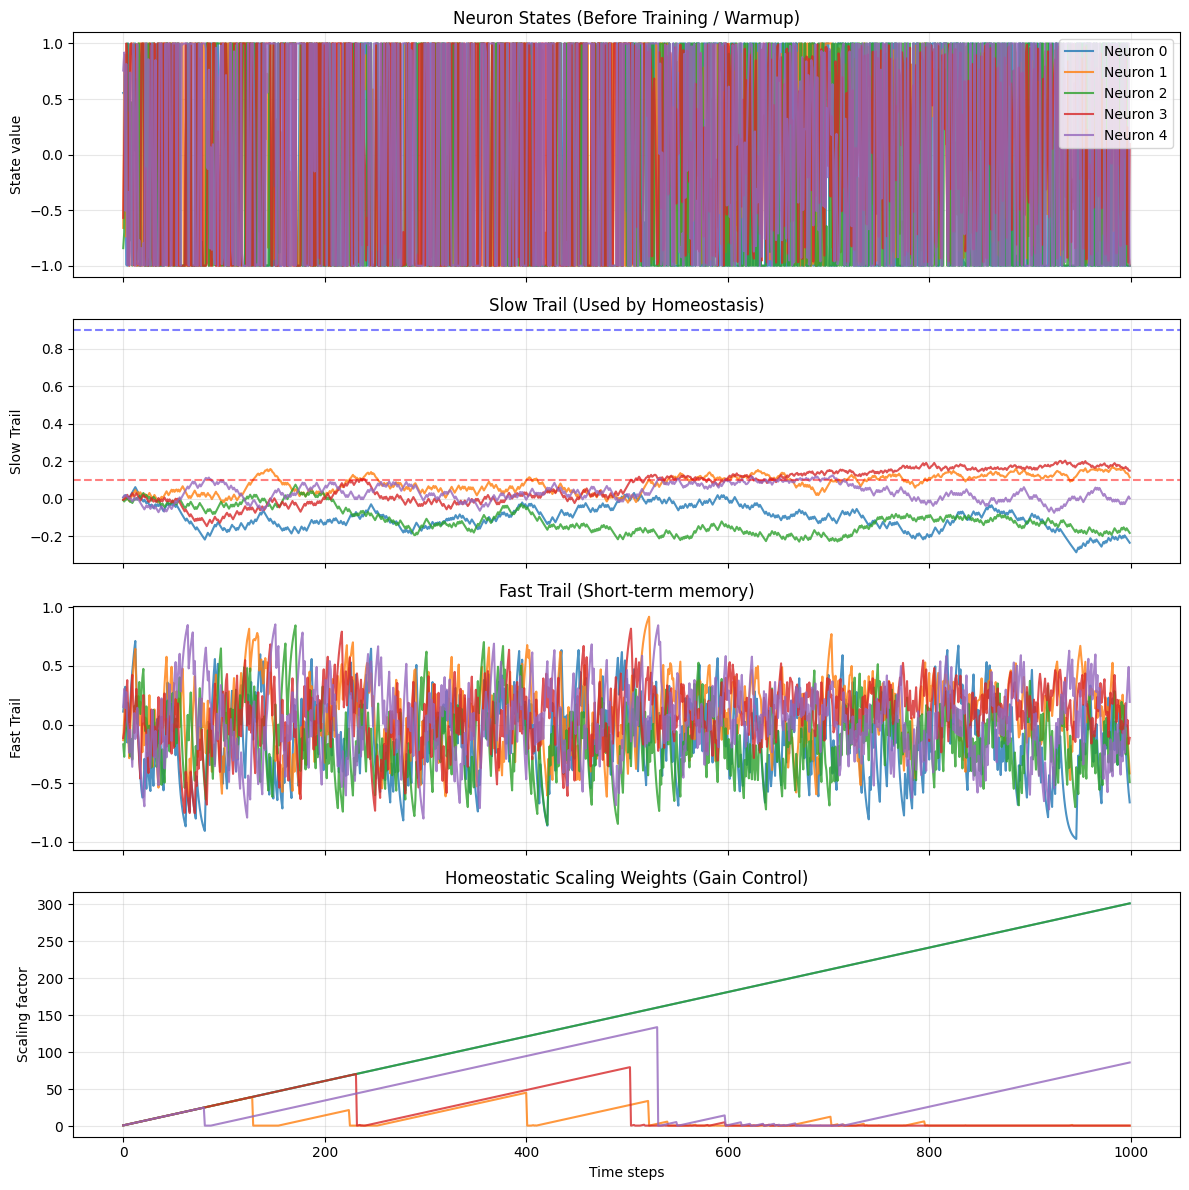

In [79]:
# 3. Plot dynamics before training
neurons_to_plot = [0, 1, 2, 3, 4]
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# States
for n in neurons_to_plot:
    axes[0].plot(states_before[:, n], label=f"Neuron {n}", alpha=0.8)
axes[0].set_ylabel("State value")
axes[0].set_title("Neuron States (Before Training / Warmup)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Slow Trail
for n in neurons_to_plot:
    axes[1].plot(slow_trail_before[:, n], alpha=0.8)
axes[1].axhline(0.1, color="red", linestyle="--", alpha=0.5, label="Low Limit (0.1)")
axes[1].axhline(0.9, color="blue", linestyle="--", alpha=0.5, label="High Limit (0.9)")
axes[1].set_ylabel("Slow Trail")
axes[1].set_title("Slow Trail (Used by Homeostasis)")
axes[1].grid(True, alpha=0.3)

# Fast Trail
for n in neurons_to_plot:
    axes[2].plot(fast_trail_before[:, n], alpha=0.8)
axes[2].set_ylabel("Fast Trail")
axes[2].set_title("Fast Trail (Short-term memory)")
axes[2].grid(True, alpha=0.3)

# Scaling
for n in neurons_to_plot:
    axes[3].plot(scaling_before[:, n], alpha=0.8)
axes[3].set_ylabel("Scaling factor")
axes[3].set_xlabel("Time steps")
axes[3].set_title("Homeostatic Scaling Weights (Gain Control)")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [80]:
# 4. Train the reservoir using Ridge Regression on a longer sequence of 100000 steps
train_len = 50000
beta = 1e-4

X = []
Y = []

reservoir.reset_state()
print("Training in progress...")
for i in range(train_len):
    char_idx = char2idx[text[i]]
    x_onehot = torch.zeros(vocab_size)
    x_onehot[char_idx] = 1.0
    
    with torch.no_grad():
        reservoir.step(x_onehot)
        
    X.append(reservoir.state.clone())
    
    next_char_idx = char2idx[text[i+1]]
    y_onehot = torch.zeros(vocab_size)
    y_onehot[next_char_idx] = 1.0
    Y.append(y_onehot)

X = torch.stack(X)
Y = torch.stack(Y)

# Solve for Readout
A = torch.matmul(X.T, X) + beta * torch.eye(res_size)
B = torch.matmul(X.T, Y)
W_out = torch.linalg.solve(A, B).T
reservoir.readout.weight.data = W_out
print("Training complete, readout weights fitted.")

Training in progress...
Training complete, readout weights fitted.


In [81]:
# 5. Record dynamics after training (in validation split)
val_steps = 1000
states_after = []
slow_trail_after = []
fast_trail_after = []
scaling_after = []

for i in range(train_len, train_len + val_steps):
    char_idx = char2idx[text[i]]
    x_onehot = torch.zeros(vocab_size)
    x_onehot[char_idx] = 1.0
    
    with torch.no_grad():
        reservoir.step(x_onehot)
        
    states_after.append(reservoir.state.clone().numpy())
    slow_trail_after.append(reservoir.slow_trail.clone().numpy())
    fast_trail_after.append(reservoir.fast_trail.clone().numpy())
    scaling_after.append(reservoir.scaling.clone().numpy())

states_after = np.stack(states_after)
slow_trail_after = np.stack(slow_trail_after)
fast_trail_after = np.stack(fast_trail_after)
scaling_after = np.stack(scaling_after)
print("Recorded post-training dynamics.")

Recorded post-training dynamics.


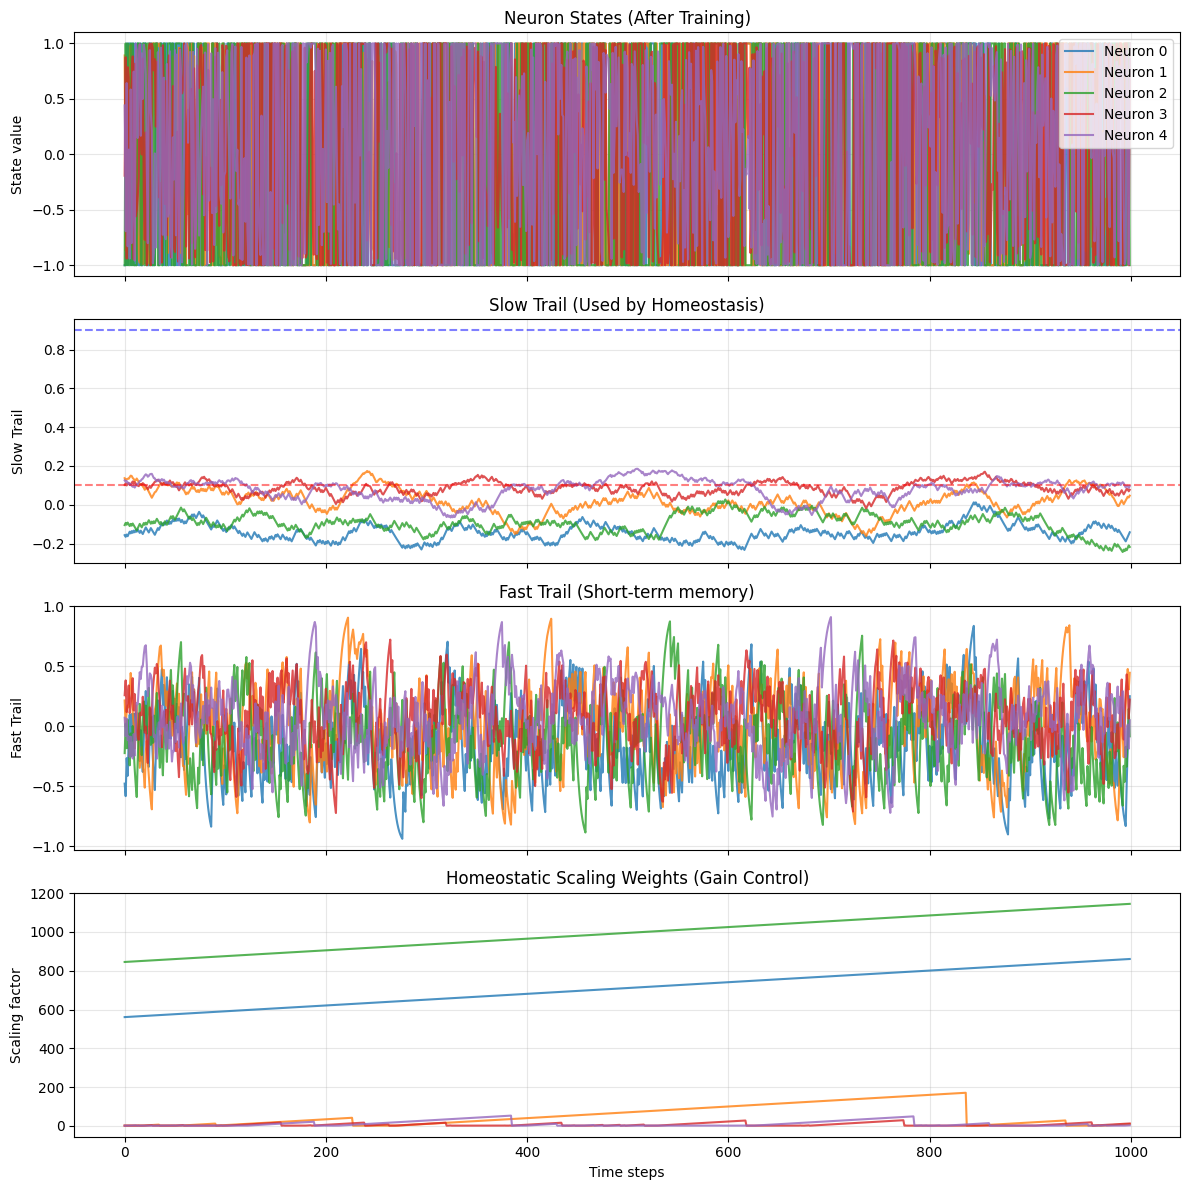

In [82]:
# 6. Plot dynamics after training
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# States
for n in neurons_to_plot:
    axes[0].plot(states_after[:, n], label=f"Neuron {n}", alpha=0.8)
axes[0].set_ylabel("State value")
axes[0].set_title("Neuron States (After Training)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Slow Trail
for n in neurons_to_plot:
    axes[1].plot(slow_trail_after[:, n], alpha=0.8)
axes[1].axhline(0.1, color="red", linestyle="--", alpha=0.5)
axes[1].axhline(0.9, color="blue", linestyle="--", alpha=0.5)
axes[1].set_ylabel("Slow Trail")
axes[1].set_title("Slow Trail (Used by Homeostasis)")
axes[1].grid(True, alpha=0.3)

# Fast Trail
for n in neurons_to_plot:
    axes[2].plot(fast_trail_after[:, n], alpha=0.8)
axes[2].set_ylabel("Fast Trail")
axes[2].set_title("Fast Trail (Short-term memory)")
axes[2].grid(True, alpha=0.3)

# Scaling
for n in neurons_to_plot:
    axes[3].plot(scaling_after[:, n], alpha=0.8)
axes[3].set_ylabel("Scaling factor")
axes[3].set_xlabel("Time steps")
axes[3].set_title("Homeostatic Scaling Weights (Gain Control)")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()